In [1]:
from helper_funcs import *
from collections import defaultdict
import numpy as np
import pandas as pd

dirs = get_dirs(root=r"c:\\Users\\setht\\Dropbox\\Citadel\\GitHub\\otocoherence")

In [13]:
# First, we gather everything from the dataframe

# Read df
df = pd.read_excel(os.path.join(
    dirs["results"], rf"soae_N_xi.xlsx"
))

dfs = {}
dfs["P"] = df[df["mode"]=="P"]
dfs["phi"] = df[df["mode"]=="phi"]

# Gather everything into lists
data = defaultdict(dict)

for mode in ["phi", "P"]:
    for prop in ["T_xi", "f0_max", "f0_fit", "species", "wf_idx"]:
        data[mode][f"{prop}s"] = np.array(dfs[mode][prop])
    # Calculate derived data
    data[mode][f"N_xis"] = data[mode][f"T_xis"] * data[mode][f"f0_maxs"]
    data[mode][f"inv_T_xis"] = 1/(data[mode][f"T_xis"])

T_xi_diffs = data["P"]["T_xis"] - data["phi"]["T_xis"]

    # titles[regime] = f"Mode={regime_dict['mode']}, {bw_str}, {win_meth_str}"



In [ ]:
"Qerb and N_xi vs Freq"

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# ======================================================

# Static
fig_fp = os.path.join(dirs["plots"], f'Qerb and N_xi vs Freq.jpg')

regime = 'static'

if 1:
    # Divide by pi
    fact = 0.1
    fact_str = f'{fact}*'
else:
    fact = 1
    fact_str = ''


# --- owl ANF tuning curve data (Excel files provided by Christine)
fp_ANFfileOwl= os.path.join(dir_otocoh, 'data', 'Owl Qerb_analysis_CK2.xlsx')
fp_ANFfileTokay= os.path.join(dir_otocoh, 'data', 'manley99.txt')
# ======================================================


# --- read in data
owlANF= pd.read_excel(fp_ANFfileOwl)
toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

# =========================
# deal w/ owl ANF vals
owlANF= owlANF[1:]  # discard first line
freqANFowl= owlANF['CF'].values
QerbANFowl= owlANF['Qerb'].values

# =========================
# deal w/ tokay ANF vals
freqANFtokay= toakyANFq10[:,0]
QerbANFtokay= 6*toakyANFq10[:,1]*1000/np.pi;  # convert to Qerb(?) via Bergevin & Shera 2010

# =======================================================================
# ==== visualize
plt.close("all")
# ------------------------------------------------
plt.figure(figsize=(9, 5))
alphas = {'Anole':0.8, 'Owl':1, 'Human':1, 'Tokay':1}
markers = {'Anole':'o', 'Owl':'d', 'Human':'x', 'Tokay':'+'}
colors = {'Anole':'k', 'Owl':'orange', 'Human':'blue', 'Tokay':'green'}
mew = {'Anole':0.5, 'Owl':2, 'Human':2, 'Tokay':2}
mfc = {'Anole':'lime', 'Owl':'none', 'Human':'none', 'Tokay':'none'}

# Plot
firsts = {"Anole": 1, "Owl": 1, "Human": 1, "Tokay": 1}

for k in range(len(N_xis[regime])):
    wf_idx, species, freq, freq_r, mse, T_xi, hwhm = (
        wf_idxs[regime][k],
        speciess[regime][k],
        freqs[regime][k],
        freqs_r[regime][k],
        mses[regime][k],
        T_xis[regime][k],
        hwhms[k],
    )
    # Skip egregious static decay or PSD Lorentzian fits
    if (species, wf_idx, freq_r) in (excluded_fits_PSD + excluded_fits_static):
        print(f"EXCLUDING {species} {wf_idx} {freq_r}Hz")
        continue
    
    # Plot
    label, firsts = get_label_from_firsts(firsts, species)
    if label is not None:
        label = rf'{species} $f/\gamma$'
    plt.plot(freq/1000, fact*freq/hwhm, markers[species], color=colors[species], markeredgewidth=mew[species], alpha=alphas[species], ms=6, markerfacecolor=mfc[species], label=label)


# Plot Q_ERB
plt.plot(freqANFtokay,QerbANFtokay,'+',color='green', alpha=0.4,ms=4,lw=1,markerfacecolor='green',label=r'Tokay $Q_{ERB}$')

plt.plot(freqANFowl,QerbANFowl,'d',color='orange', alpha=0.3,ms=3,lw=1,markerfacecolor='orange',label=r'Owl $Q_{ERB}$')

# ---
plt.xscale('log')
plt.yscale('log')

plt.xlim([0.1,12])
# plt.ylim([0.8,2000])
plt.xlabel('Frequency [kHz]', fontsize=fsz-4)
plt.ylabel(rf'SOAE ${fact_str}f/\gamma$ & ANF $Q_{{ERB}}$', fontsize=fsz-4) 
plt.grid(True, which="both", ls="-", color='0.9')
plt.legend(fontsize=fsz-4)
 
plt.savefig(fig_fp, dpi=dpi, bbox_inches='tight')
plt.show()

In [4]:
import numpy as np
acf = np.ones(4)
lag_s = np.arange(4)
print(acf)
print(lag_s)
T_xi = get_T_xi_eta(acf, lag_s, eta=0.5)
print(T_xi)

[1. 1. 1. 1.]
[0 1 2 3]
1


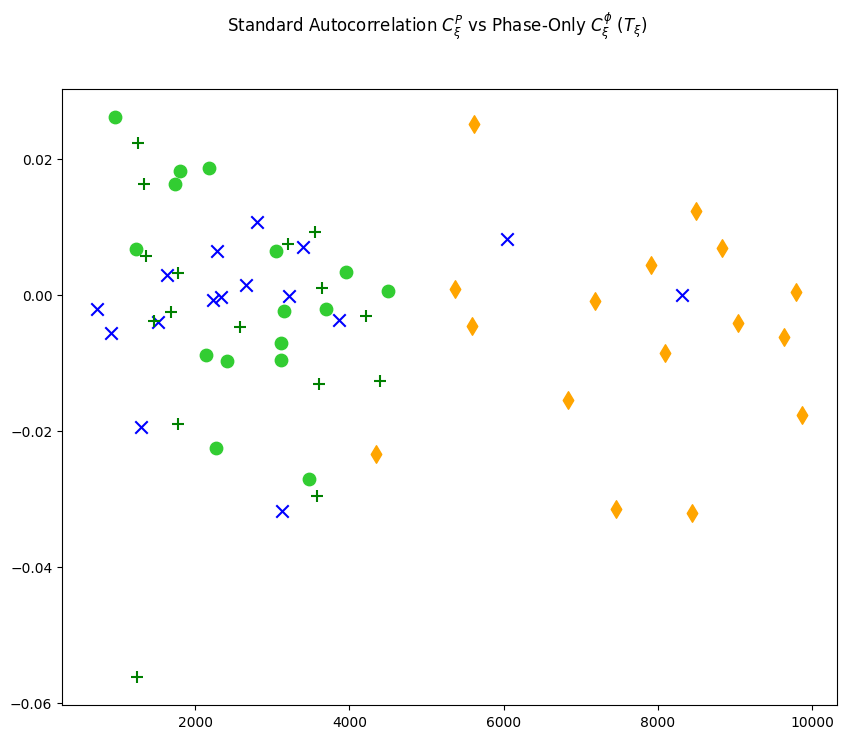

In [15]:
"Standard Autocorrelation vs Phase-Only (T_xi)"
# Initialize plot
plt.figure(figsize=(10, 8))
plt.suptitle(rf"Standard Autocorrelation $C_\xi^P$ vs Phase-Only $C_\xi^\phi$ ($T_\xi$)")
fn_plot = f'Phase only vs ACF (T_xi).jpg'

f0_maxs = data["P"]["f0_maxs"]
speciess = data["P"]["speciess"]

if np.max(np.abs(f0_maxs-data["phi"]["f0_maxs"])) > 0 or np.any(speciess != data["phi"]["speciess"]):
    raise ValueError("Frequencies and species should agree between modes!")


markers = {
    "Anole": ("limegreen", "o"),
    "Owl": ("orange", "d"),
    "Human": ("blue", "x"),
    "Tokay": ("green", "+"),
}

unique_species = ["Anole", "Human", "Tokay", "Owl"]

for species in unique_species:
    f0_maxs_plot = [this_f0_max for this_f0_max, this_species in zip(f0_maxs, speciess) if this_species == species]
    T_xi_diff_plot = [this_T_xi_diff for this_T_xi_diff, this_species in zip(T_xi_diffs, speciess) if this_species == species]
    plt.scatter(f0_maxs_plot, T_xi_diff_plot, 
                label=species,
                color=markers[species][0],
                marker=markers[species][1],
                s=80)


